In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as optimization

In [4]:
NUM_TRADING_DAYS = 252       # Average trading days in a year
NUM_PORTFOLIOS = 10000       # Number of random portfolios to simulate
stocks = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN', 'DB']  # Stock symbols

start_date = '2010-01-01'
end_date = '2017-01-01'

In [5]:
def download_data(stocks, start_date, end_date):
    data = {}
    for stock in stocks:
        ticker = yf.Ticker(stock)
        data[stock] = ticker.history(start=start_date, end=end_date)['Close']
    return pd.DataFrame(data)

# Fetch data
price_data = download_data(stocks, start_date, end_date)

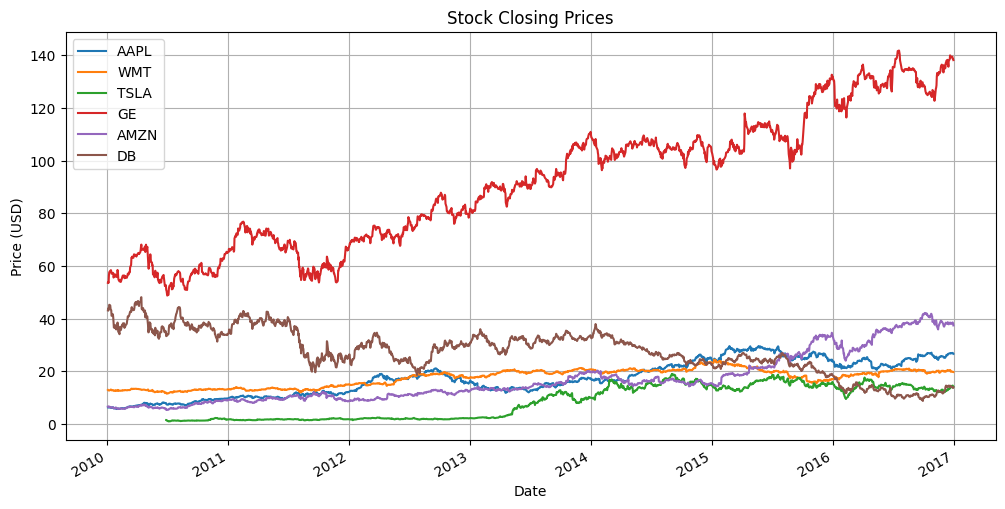

In [6]:
def plot_price_data(data):
    data.plot(figsize=(12, 6), title='Stock Closing Prices')
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.show()

plot_price_data(price_data)

In [15]:
#Calculate Daily Log Returns
def calculate_log_returns(data):
    return np.log(data / data.shift(1)).dropna()

log_returns = calculate_log_returns(price_data)

In [14]:
#Portfolio Return & Volatility Calculation
def calculate_portfolio_performance(weights, returns):
    mean_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    risk = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * NUM_TRADING_DAYS, weights)))
    sharpe = mean_return / risk
    return mean_return, risk, sharpe

In [16]:
def generate_random_portfolios(returns, num_portfolios):
    means = []
    risks = []
    weights_list = []

    for _ in range(num_portfolios):
        weights = np.random.random(len(stocks))
        weights /= np.sum(weights)
        ret, vol, _ = calculate_portfolio_performance(weights, returns)
        weights_list.append(weights)
        means.append(ret)
        risks.append(vol)

    return np.array(weights_list), np.array(means), np.array(risks)

weights, means, risks = generate_random_portfolios(log_returns, NUM_PORTFOLIOS)

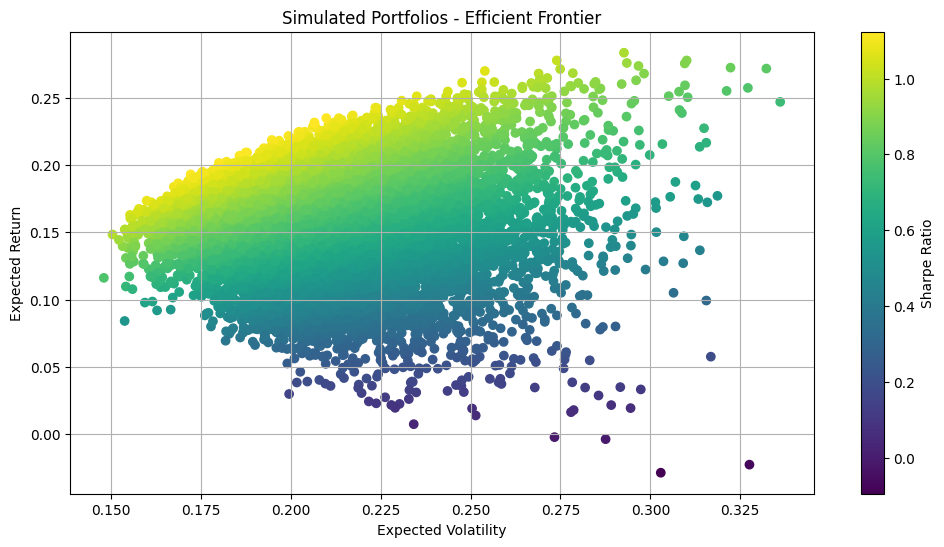

In [17]:
def plot_efficient_frontier(returns, risks):
    plt.figure(figsize=(12, 6))
    plt.scatter(risks, returns, c=returns / risks, marker='o', cmap='viridis')
    plt.colorbar(label='Sharpe Ratio')
    plt.title("Simulated Portfolios - Efficient Frontier")
    plt.xlabel("Expected Volatility")
    plt.ylabel("Expected Return")
    plt.grid(True)
    plt.show()

plot_efficient_frontier(means, risks)

In [20]:
#Creating and optimizing portfolio
def negative_sharpe(weights, returns):
    return -calculate_portfolio_performance(weights, returns)[2]

def optimize_portfolio(returns):
    init_guess = np.ones(len(stocks)) / len(stocks)
    bounds = tuple((0, 1) for _ in stocks)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    
    result = optimization.minimize(fun=negative_sharpe,
                                   x0=init_guess,
                                   args=(returns,),
                                   method='SLSQP',
                                   bounds=bounds,
                                   constraints=constraints)
    return result

opt_result = optimize_portfolio(log_returns)

In [22]:
def display_optimal_portfolio(result, returns):
    weights = result.x.round(4)
    expected_return, volatility, sharpe = calculate_portfolio_performance(weights, returns)

    print("Optimal Portfolio Allocation:")
    for stock, weight in zip(stocks, weights):
        print(f"{stock}: {weight * 100:.2f}%")
    print(f"\n Expected Annual Return: {expected_return:.2f}")
    print(f" Expected Volatility: {volatility:.2f}")
    print(f" Sharpe Ratio: {sharpe:.2f}")

display_optimal_portfolio(opt_result, log_returns)

Optimal Portfolio Allocation:
AAPL: 23.60%
WMT: 14.81%
TSLA: 9.86%
GE: 20.13%
AMZN: 31.60%
DB: 0.00%

 Expected Annual Return: 0.21
 Expected Volatility: 0.19
 Sharpe Ratio: 1.14
